# Kalimati Price Forecasting - Publication Quality Visualizations
This notebook generates high-DPI, publication-ready figures for the research paper. It covers Exploratory Data Analysis, STL Decomposition, Statistical assumptions, and Final Forecast results.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

# Output directory
out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Global publication style
# -----------------------------
sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="deep"
)

mpl.rcParams.update({
    # Fonts
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,

    # Figure export
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",

    # Text sizes
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    # Axes and grid
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,

    # Lines
    "lines.linewidth": 2.2,
    "lines.markersize": 5,

    # Ticks
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    # Legend
    "legend.frameon": False,

    # Layout
    "figure.autolayout": False,
})

# Consistent color system
primary_color = "#1F77B4"     # strong blue
secondary_color = "#D62728"   # red
accent_color = "#2CA02C"      # green
neutral_color = "#4D4D4D"     # dark gray
light_gray = "#BDBDBD"

palette = {
    "primary": primary_color,
    "secondary": secondary_color,
    "accent": accent_color,
    "neutral": neutral_color,
    "light_gray": light_gray,
}

print("Publication-ready plotting environment configured.")

Publication-ready plotting environment configured.


Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/01_kvpi_price_series.png


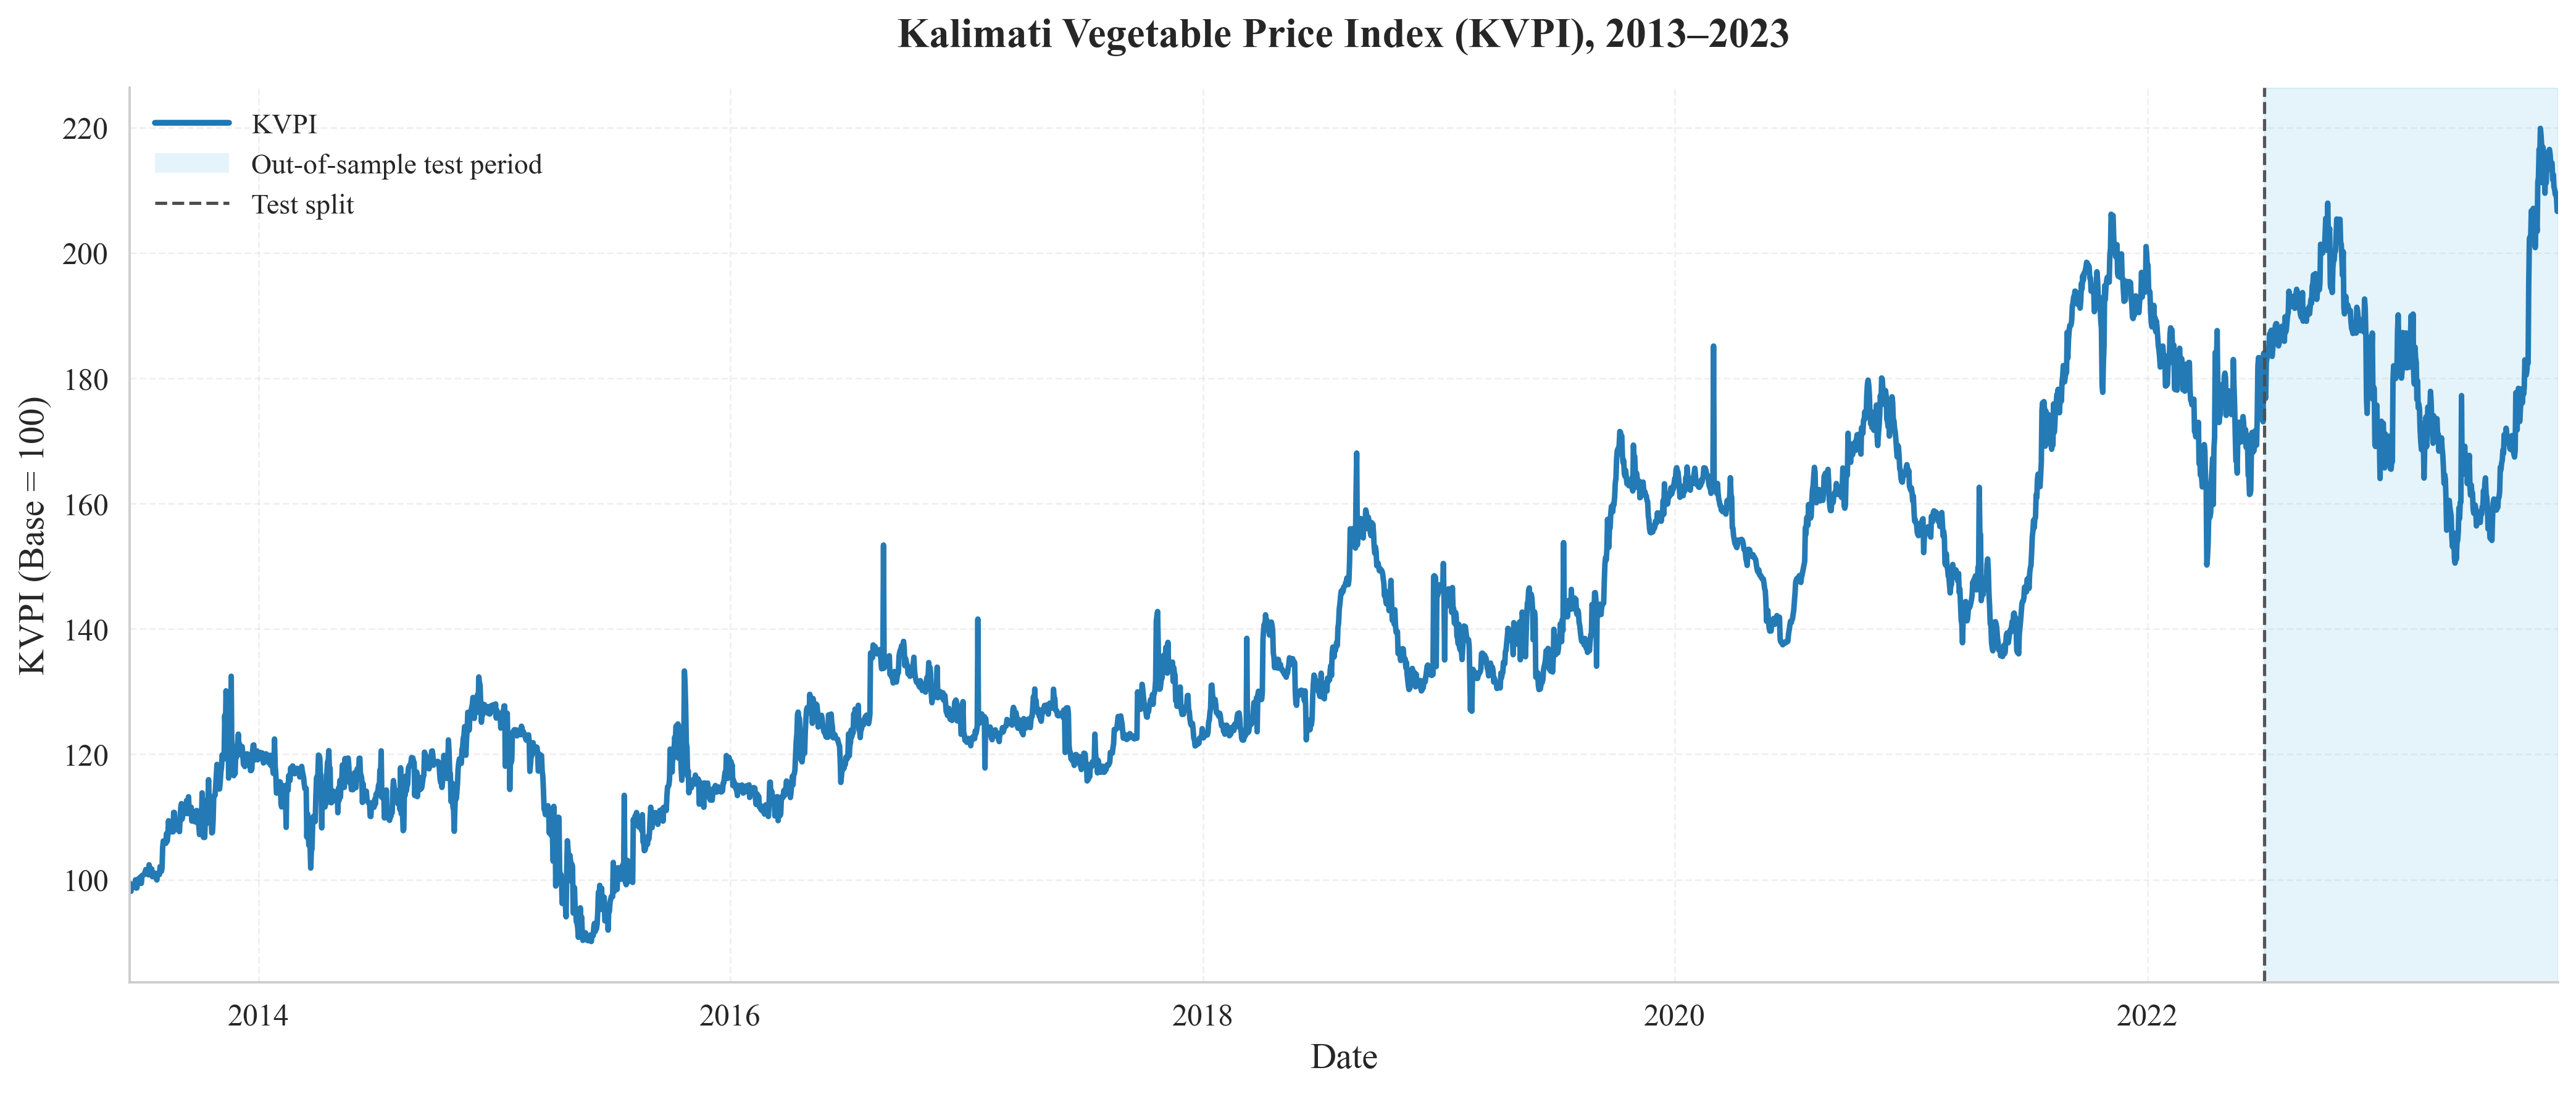

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Robust output directory
out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# Publication style
sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "lines.linewidth": 2.3,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})

# Colors
primary_color = "#1F77B4"
skyblue = "#87CEEB"
neutral_color = "#4D4D4D"

# Load data
df = pd.read_csv("outputs/cleaned_data/kalimati_kvpi.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df.index,
    df["KVPI"],
    color=primary_color,
    linewidth=2.15,
    alpha=0.98
)

test_start = pd.to_datetime("2022-07-01")
test_end = df.index.max()

ax.axvspan(
    test_start,
    test_end,
    color=skyblue,
    alpha=0.22
)
ax.axvline(
    test_start,
    color=neutral_color,
    linestyle="--",
    linewidth=1.25,
    alpha=0.95
)

ax.set_title("Kalimati Vegetable Price Index (KVPI), 2013–2023", pad=16, fontweight="bold")
ax.set_ylabel("KVPI (Base = 100)")
ax.set_xlabel("Date")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.margins(x=0)
ax.grid(True, which="major", axis="both")

legend_handles = [
    Line2D([0], [0], color=primary_color, lw=2.3, label="KVPI"),
    Patch(facecolor=skyblue, edgecolor="none", alpha=0.22, label="Out-of-sample test period"),
    Line2D([0], [0], color=neutral_color, lw=1.25, linestyle="--", label="Test split"),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=False, handlelength=2.6)

sns.despine(ax=ax)
fig.tight_layout()

save_path = out_dir / "01_kvpi_price_series.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/02_kvpi_decomposition.png


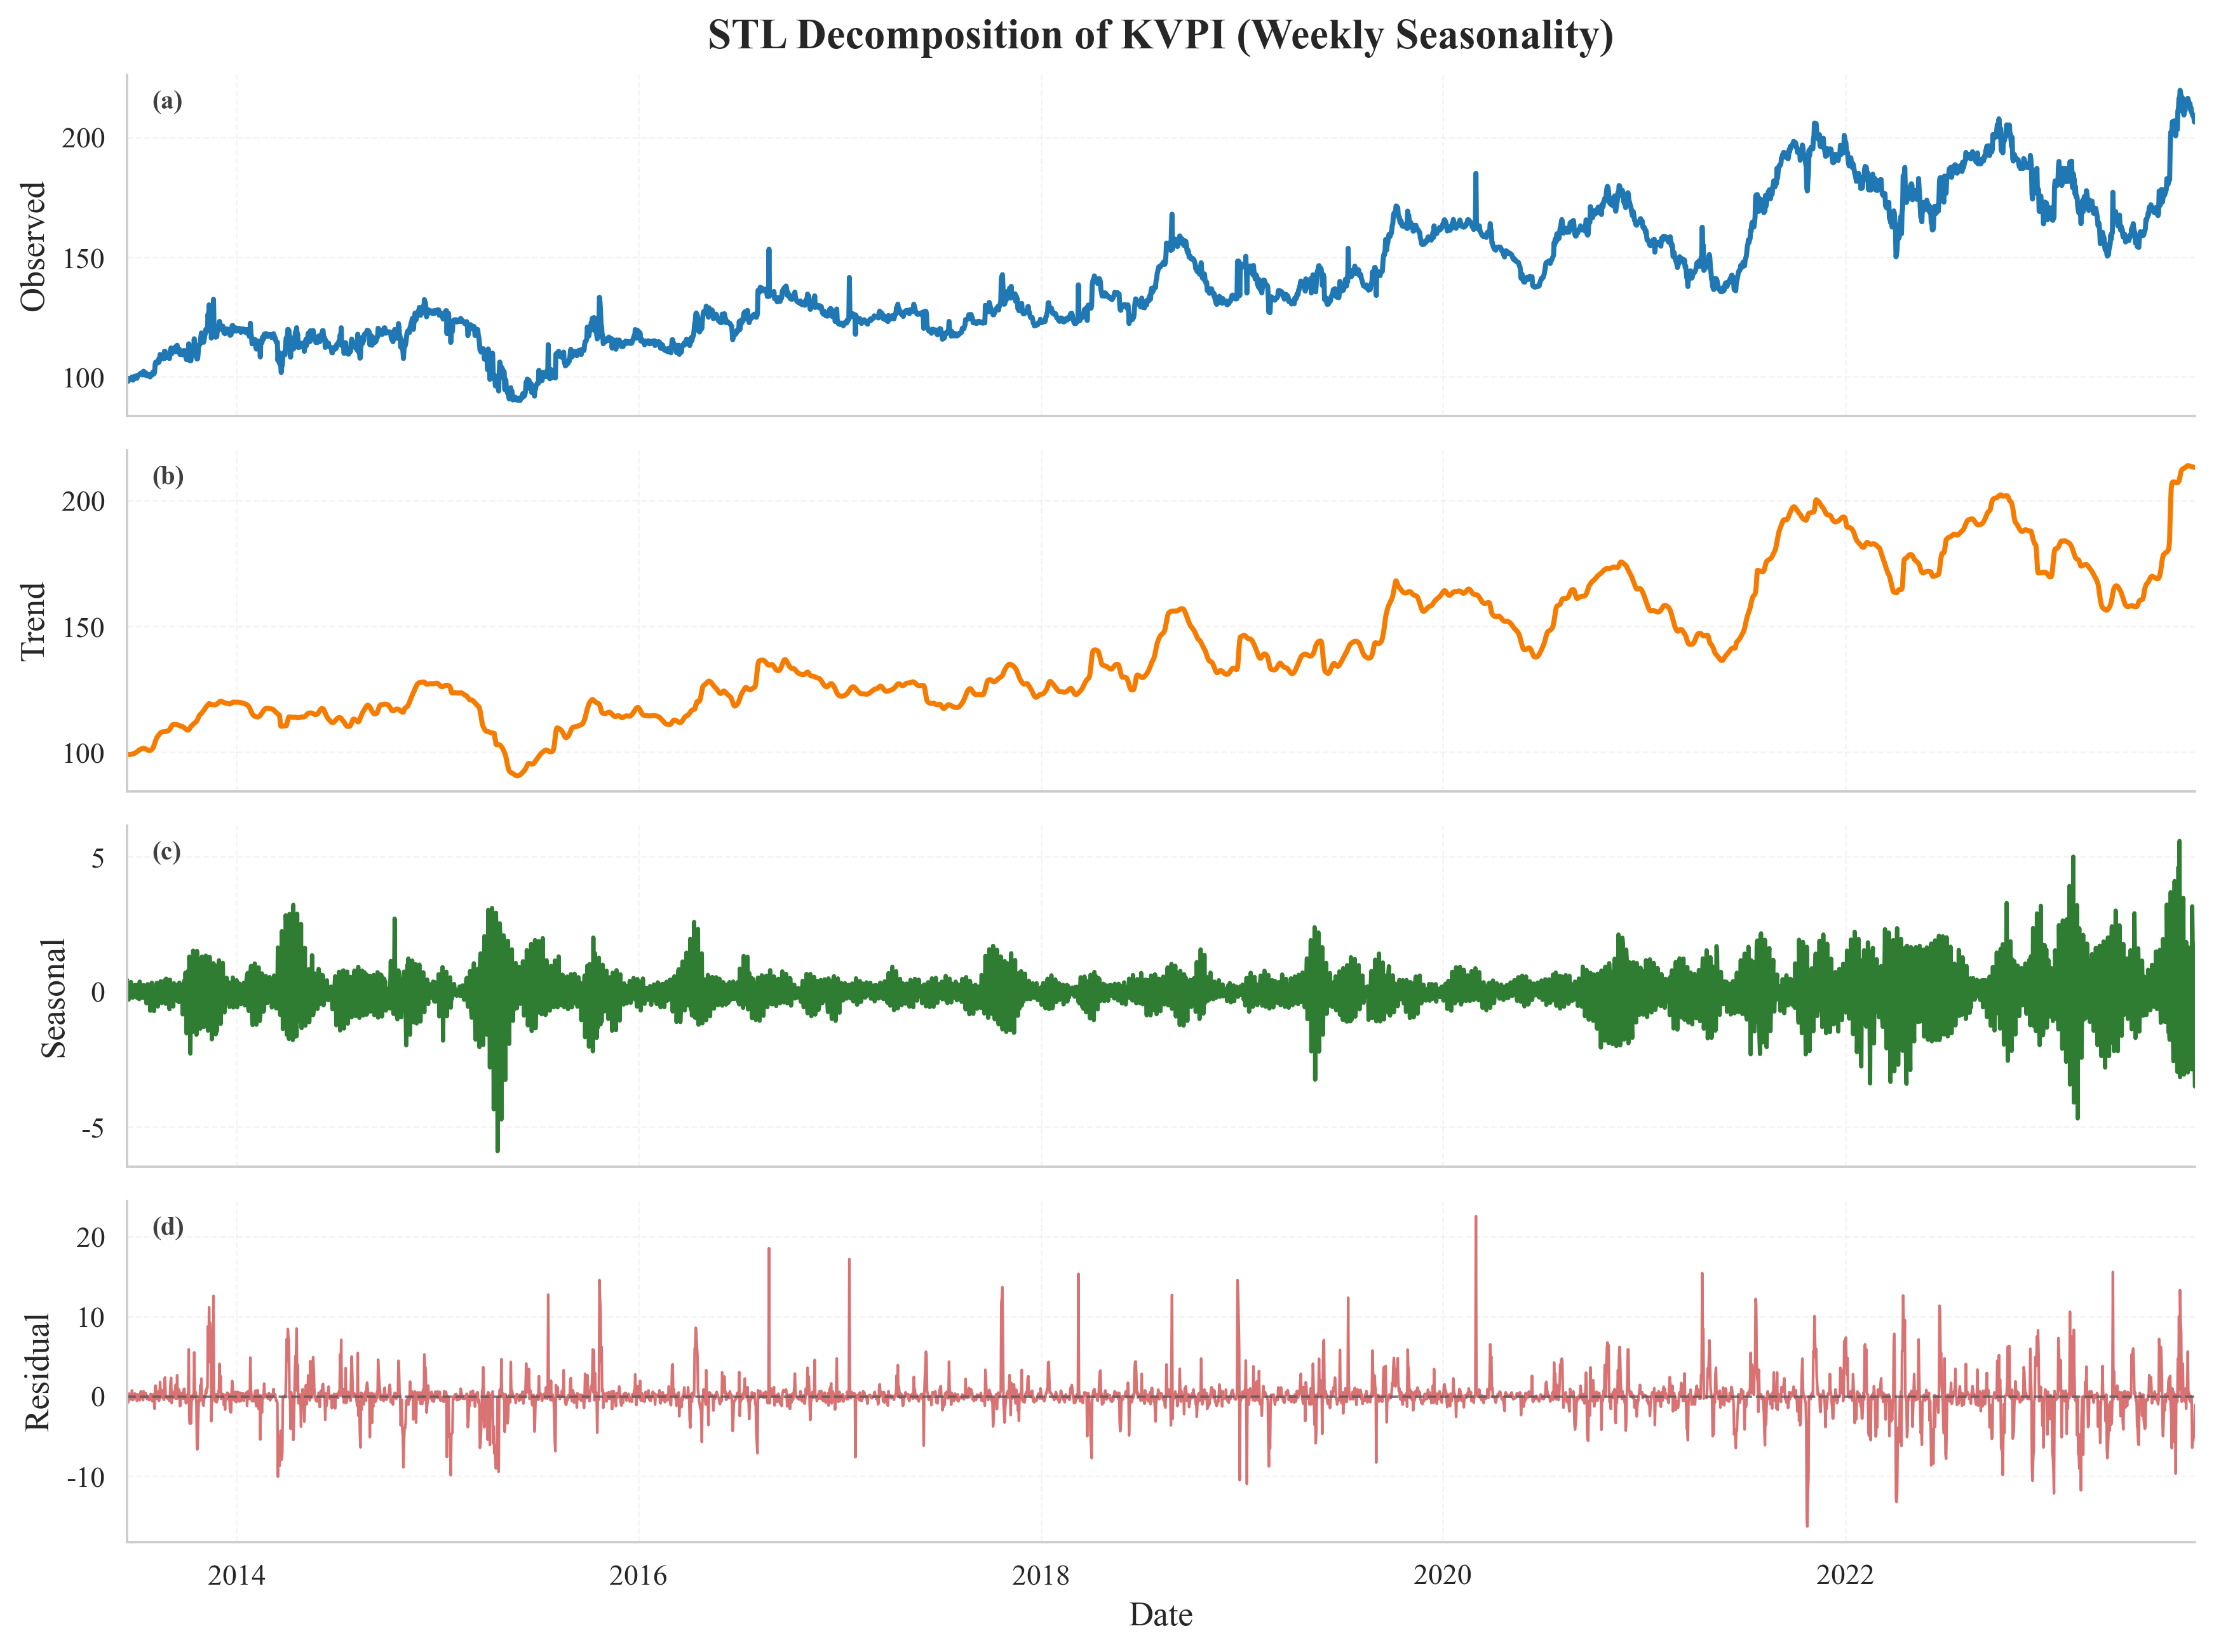

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import STL

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "lines.linewidth": 1.9,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})

df = pd.read_csv("outputs/cleaned_data/kalimati_kvpi.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

res = STL(df["KVPI"], period=7, robust=True).fit()

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.10}
)

colors = {
    "observed": "#1F77B4",
    "trend": "#F57C00",
    "seasonal": "#2E7D32",
    "resid": "#C62828",
}

axes[0].plot(df.index, df["KVPI"], color=colors["observed"], linewidth=1.9)
axes[0].set_ylabel("Observed")
axes[0].set_title("STL Decomposition of KVPI (Weekly Seasonality)", fontweight="bold", pad=10)

axes[1].plot(df.index, res.trend, color=colors["trend"], linewidth=1.9)
axes[1].set_ylabel("Trend")

axes[2].plot(df.index, res.seasonal, color=colors["seasonal"], linewidth=1.6)
axes[2].set_ylabel("Seasonal")

axes[3].plot(df.index, res.resid, color=colors["resid"], alpha=0.65, linewidth=1.0)
axes[3].axhline(0, color="0.35", linewidth=0.9, linestyle="--", alpha=0.8)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")

for ax in axes:
    ax.grid(True, which="major", axis="y")
    ax.margins(x=0)
    sns.despine(ax=ax)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].xaxis.set_minor_locator(mdates.YearLocator(1))

panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, lab in zip(axes, panel_labels):
    ax.text(
        0.012, 0.90, lab,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        color="0.25"
    )

fig.tight_layout()
save_path = out_dir / "02_kvpi_decomposition.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")
plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/03_kvpi_festival_heatmap.png


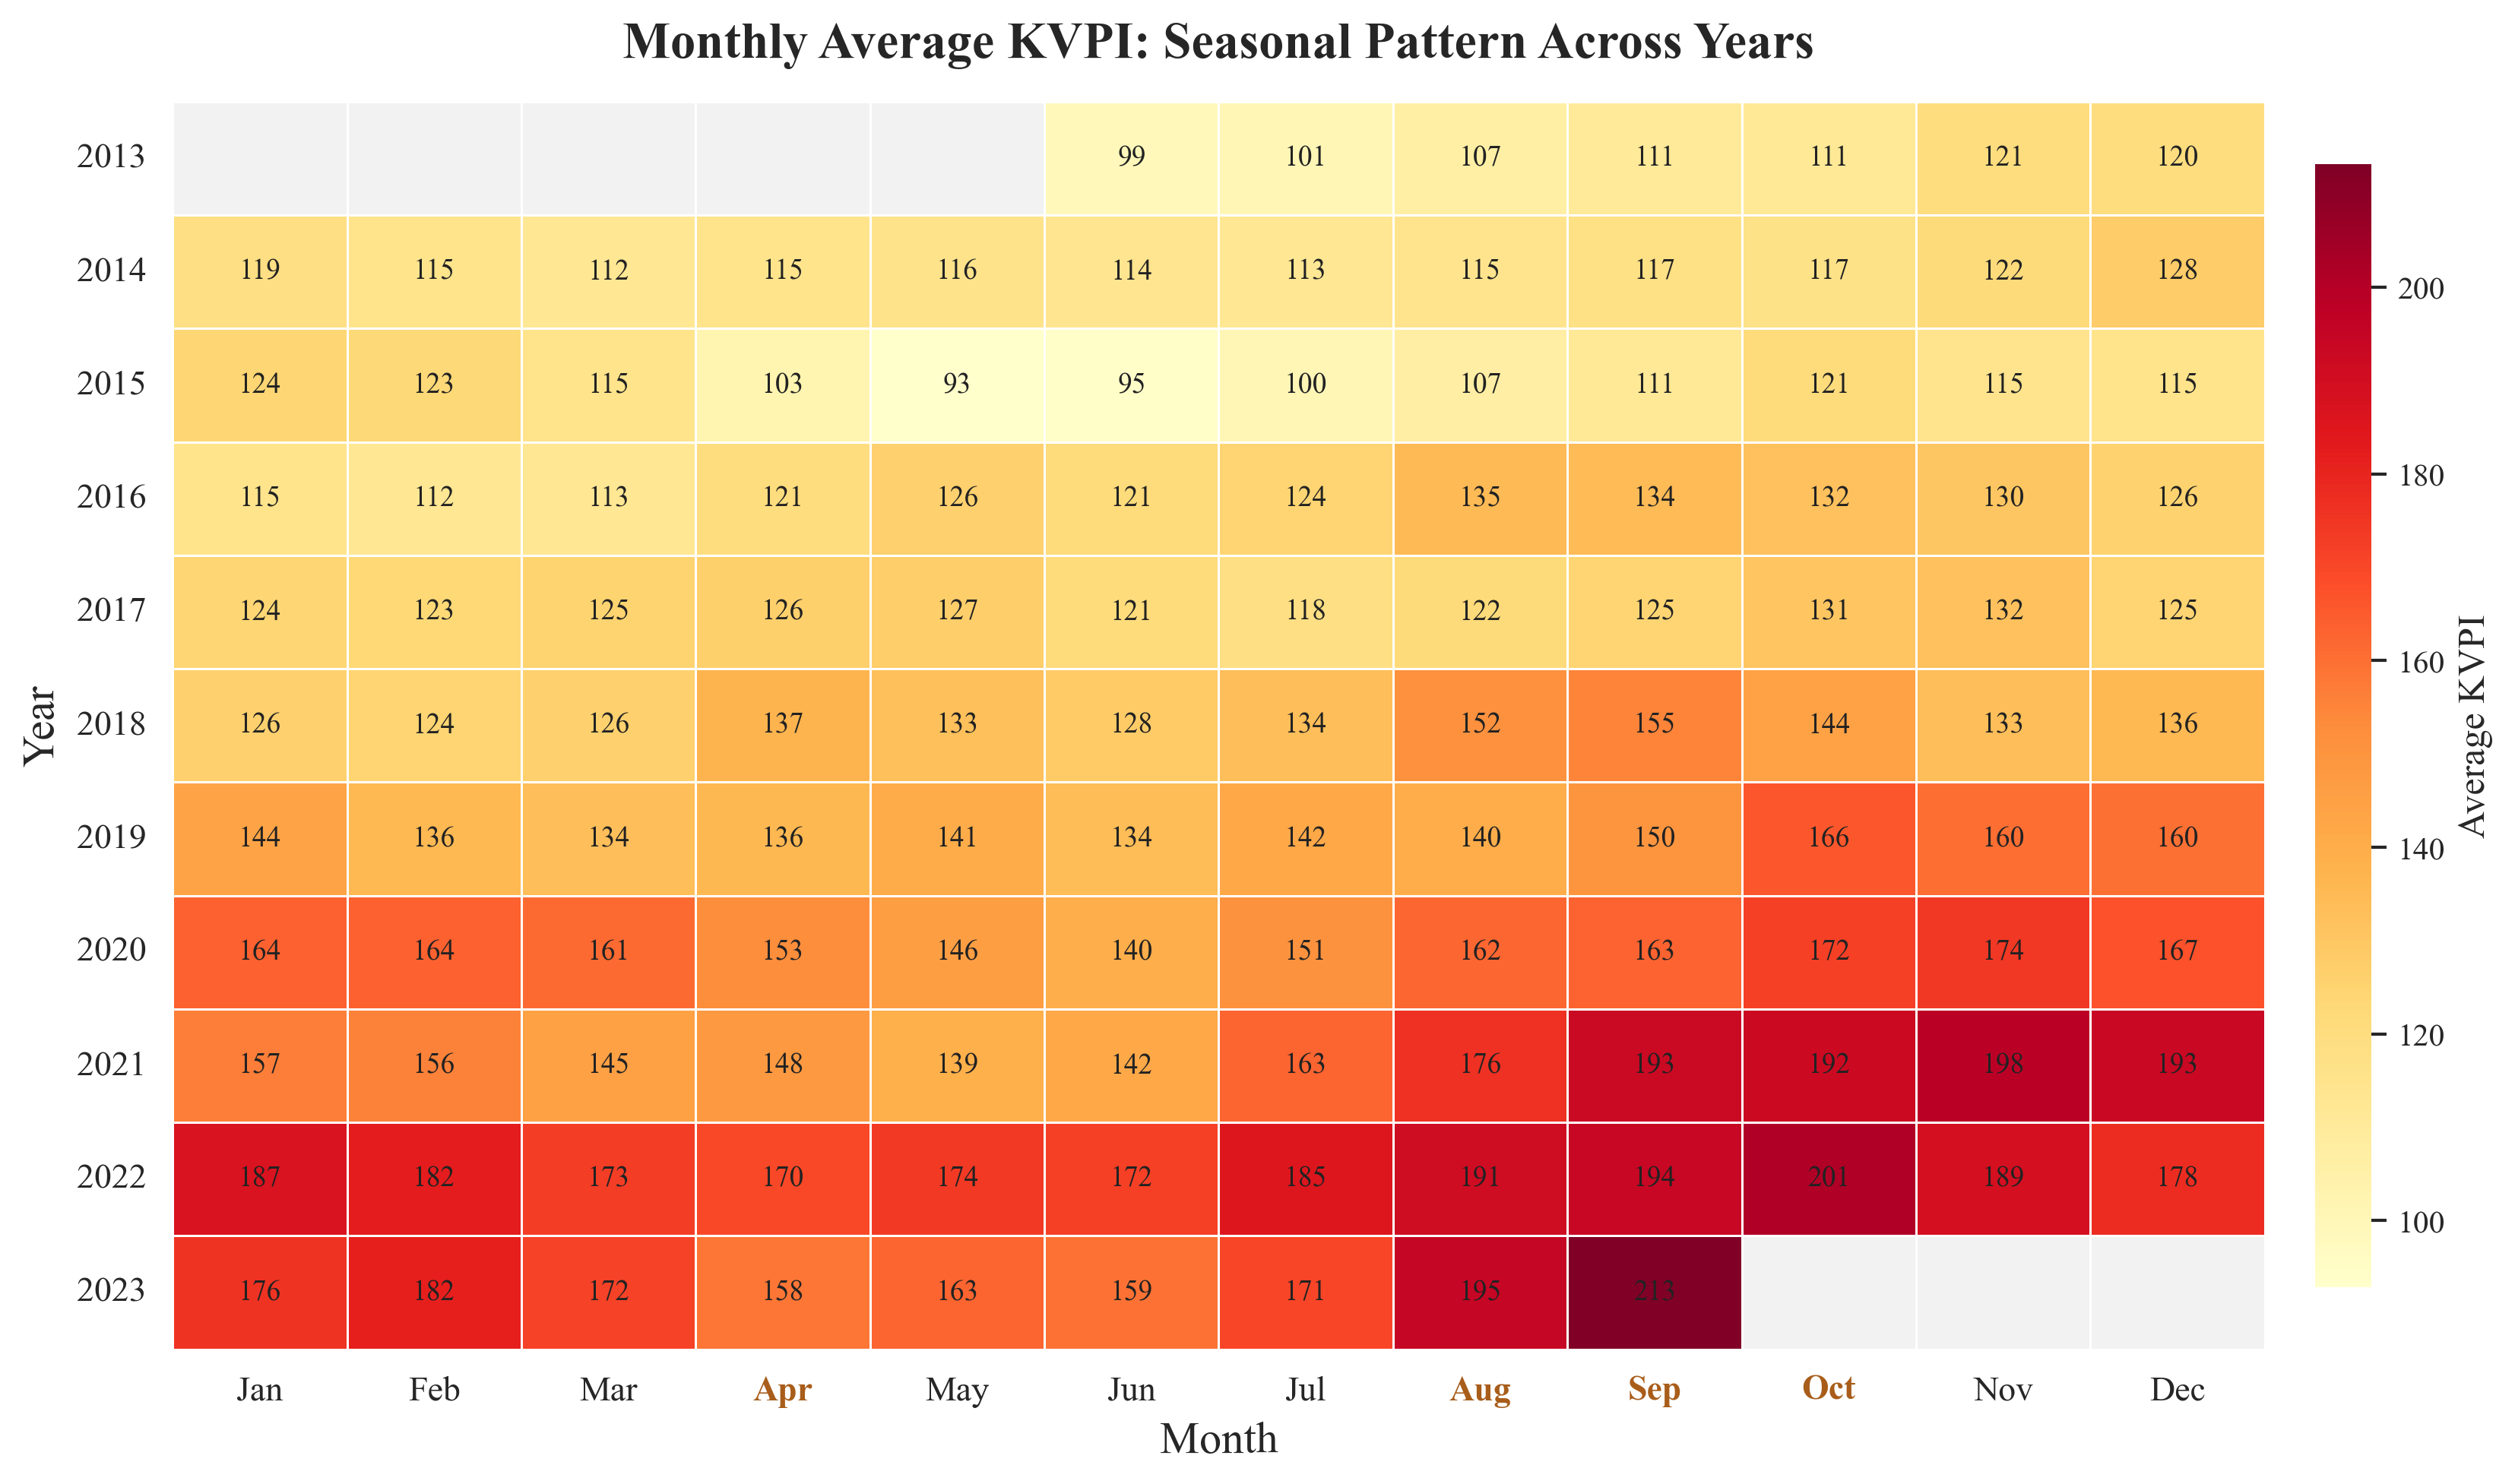

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Output directory
out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# Publication style
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "axes.unicode_minus": False,
})

# Load data
df = pd.read_csv("outputs/cleaned_data/kalimati_kvpi.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

# Monthly averages
monthly = df["KVPI"].resample("ME").mean().to_frame("KVPI")
monthly["Year"] = monthly.index.year
monthly["Month"] = monthly.index.month

pivot = monthly.pivot_table(
    values="KVPI",
    index="Year",
    columns="Month",
    aggfunc="mean"
)

pivot = pivot.reindex(index=range(2013, 2024), columns=range(1, 13))

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

mask = pivot.isna()

fig, ax = plt.subplots(figsize=(12, 6.6))

cmap = sns.color_palette("YlOrRd", as_cmap=True)
cmap.set_bad(color="#F2F2F2")  # light gray for missing months

hm = sns.heatmap(
    pivot,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".0f",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={
        "label": "Average KVPI",
        "shrink": 0.9,
        "pad": 0.02
    },
    annot_kws={
        "fontsize": 9,
        "color": "#222222"
    },
    ax=ax
)

ax.set_title(
    "Monthly Average KVPI: Seasonal Pattern Across Years",
    pad=14,
    fontweight="bold"
)
ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticklabels(month_labels, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Optional subtle highlighting of major festival-related months
festival_months = [4, 8, 9, 10]  # Apr, Aug, Sep, Oct
for i, label in enumerate(ax.get_xticklabels(), start=1):
    if i in festival_months:
        label.set_fontweight("bold")
        label.set_color("#A85D1A")

# Clean colorbar
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Average KVPI", fontsize=12)

sns.despine(left=True, bottom=True)
fig.tight_layout()

save_path = out_dir / "03_kvpi_festival_heatmap.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/04_kvpi_acf_pacf.png


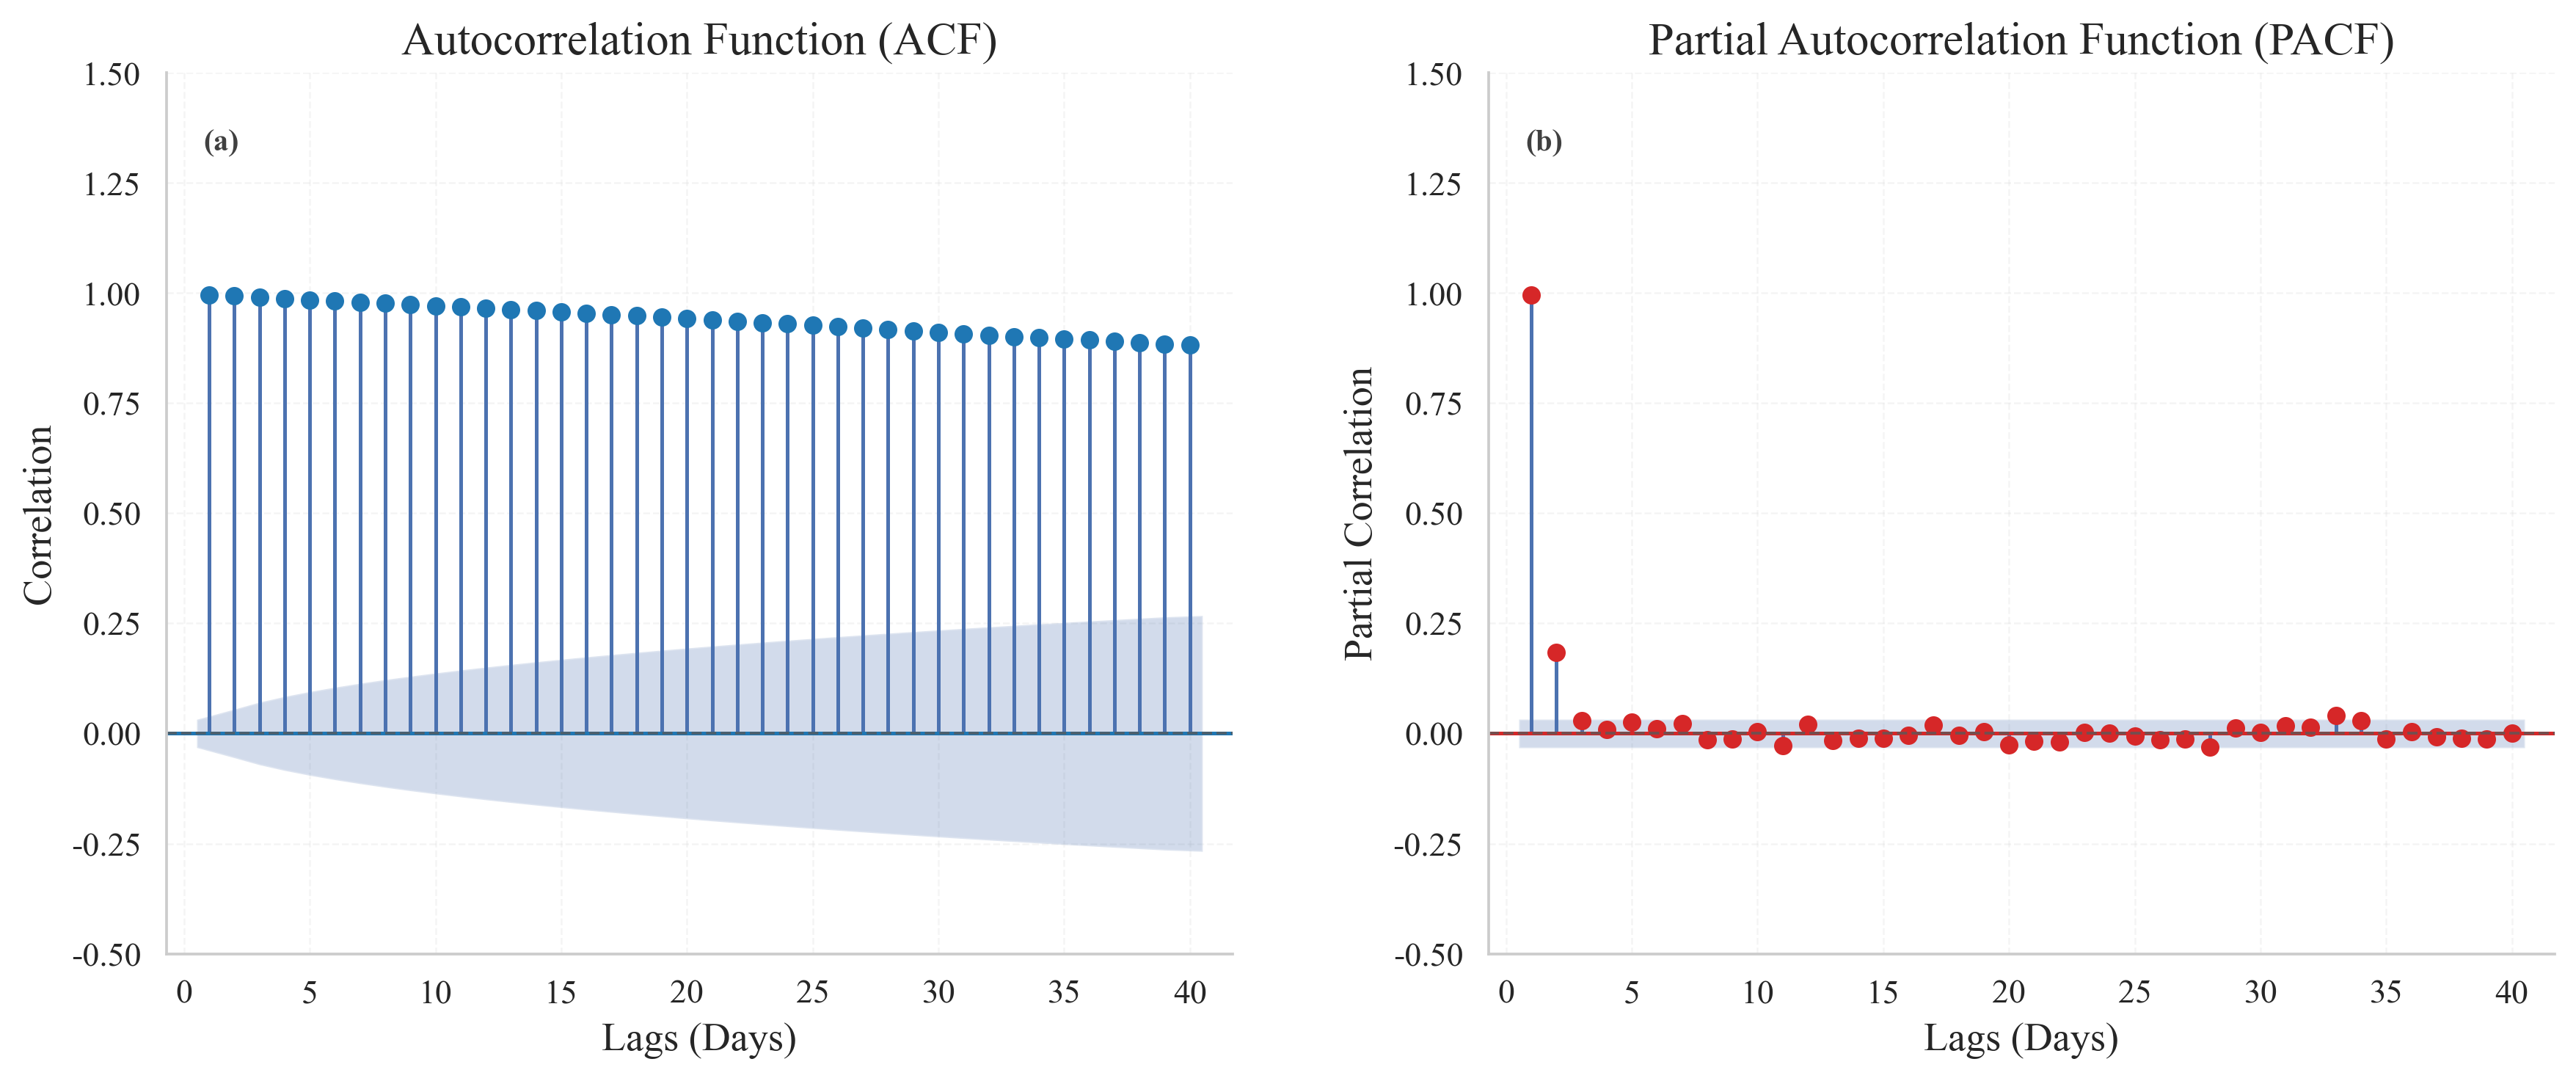

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})

df = pd.read_csv("outputs/cleaned_data/kalimati_kvpi.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

series = df["KVPI"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.2),
    gridspec_kw={"wspace": 0.24}
)

plot_acf(
    series,
    lags=40,
    ax=axes[0],
    color="#1F77B4",
    alpha=0.05,
    zero=False,
    title="Autocorrelation Function (ACF)"
)

plot_pacf(
    series,
    lags=40,
    ax=axes[1],
    color="#D62728",
    alpha=0.05,
    method="ywm",
    zero=False,
    title="Partial Autocorrelation Function (PACF)"
)

for ax in axes:
    ax.set_xlabel("Lags (Days)")
    ax.axhline(0, color="0.35", linewidth=0.9, linestyle="--", alpha=0.8)
    ax.grid(True, axis="y")
    sns.despine(ax=ax)
    ax.margins(x=0.03)

axes[0].set_ylabel("Correlation")
axes[1].set_ylabel("Partial Correlation")

# More room at top and bottom
axes[0].set_ylim(-0.5, 1.5)
axes[1].set_ylim(-0.5, 1.5)

# Move labels inward and down so they never touch stems/spikes
axes[0].text(
    0.035, 0.935, "(a)",
    transform=axes[0].transAxes,
    fontsize=10,
    fontweight="bold",
    color="0.25",
    ha="left",
    va="top"
)

axes[1].text(
    0.035, 0.935, "(b)",
    transform=axes[1].transAxes,
    fontsize=10,
    fontweight="bold",
    color="0.25",
    ha="left",
    va="top"
)

fig.tight_layout()
save_path = out_dir / "04_kvpi_acf_pacf.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/05_stacking_ensemble_forecast.png


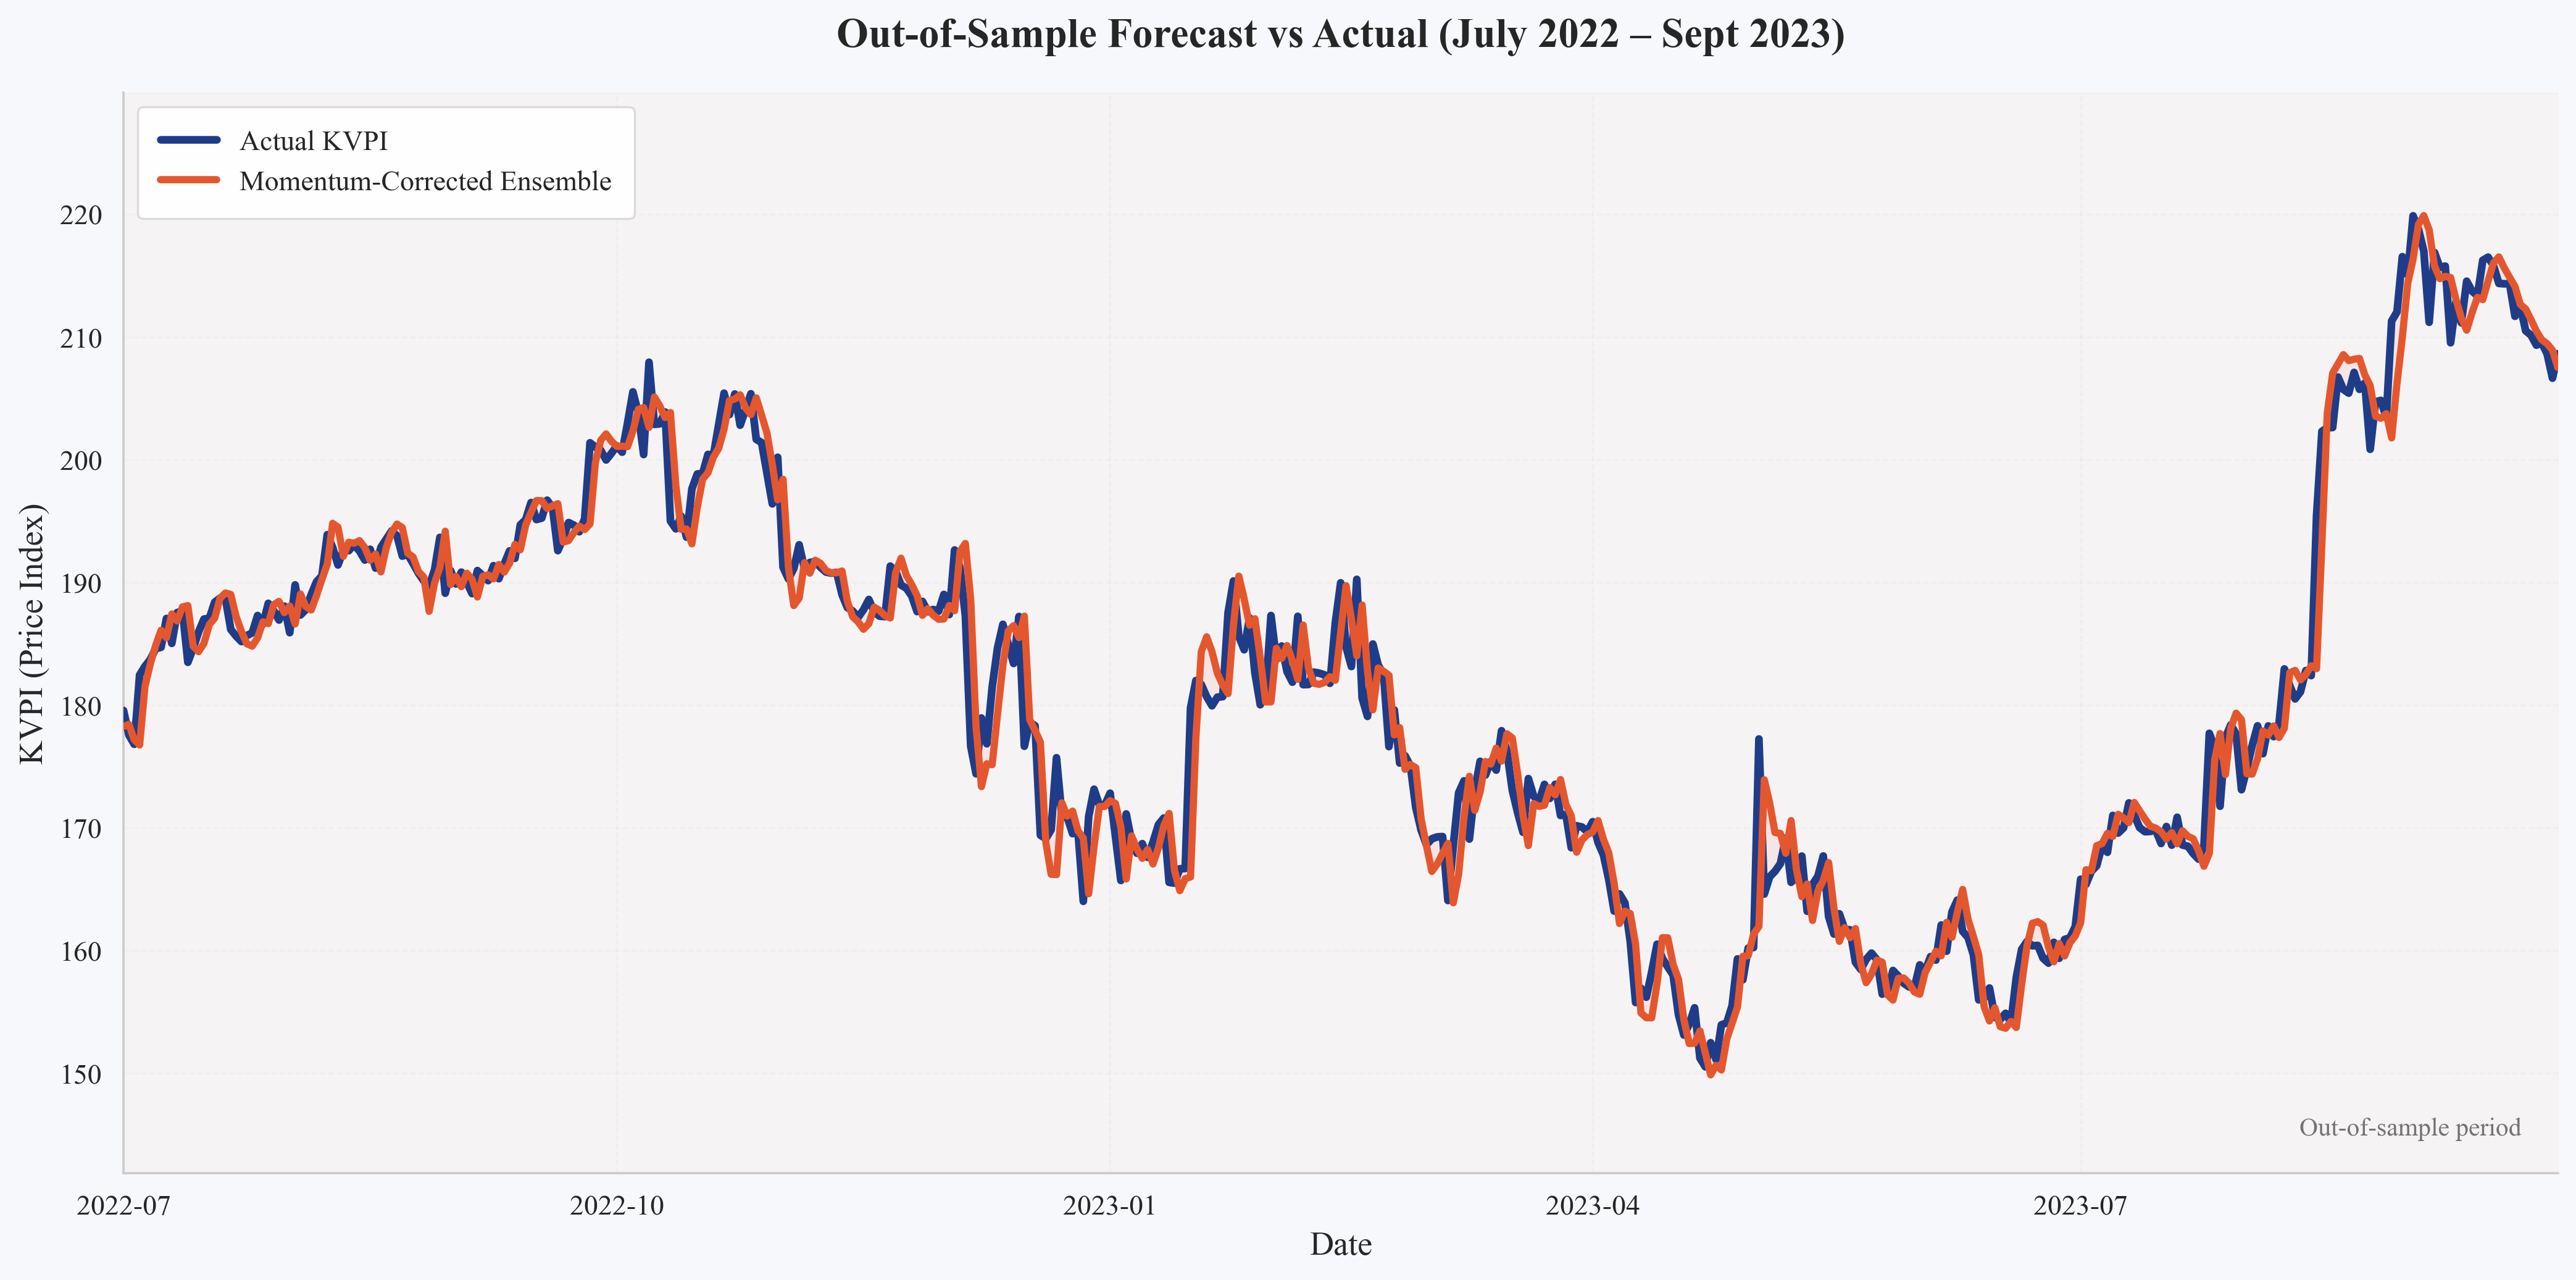

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.14,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})

# Colors
actual_color = "#1F3C88"      # deep black-blue
ensemble_color = "#E4572E"    # orange-red
bg_top = "#f7f8fc"
bg_bottom = "#fbfcff"

# Load data
df = pd.read_csv("outputs/cleaned_data/kalimati_kvpi.csv", parse_dates=["Date"])
df = df.set_index("Date").sort_index()

test_actual = df[df.index >= "2022-07-01"].copy()
ens_df = pd.read_csv("outputs/reports/kvpi_stackingensemble_predictions.csv")

min_len = min(len(test_actual), len(ens_df))
test_dates = test_actual.index[:min_len]
actual_vals = test_actual["KVPI"].values[:min_len]
ens_pred = ens_df["prediction"].values[:min_len]

fig, ax = plt.subplots(figsize=(14, 7))

# Background
fig.patch.set_facecolor(bg_top)
ax.set_facecolor(bg_bottom)

# Soft atmospheric shading
ax.axvspan(test_dates[0], test_dates[-1], color="#f2c7a3", alpha=0.12, zorder=0)
ax.axhspan(actual_vals.min() - 15, actual_vals.max() + 15, color="#e8eefb", alpha=0.20, zorder=0)

# Main lines
ax.plot(
    test_dates, actual_vals,
    label="Actual KVPI",
    color=actual_color,
    linewidth=3.0,
    zorder=4
)

ax.plot(
    test_dates, ens_pred,
    label="Momentum-Corrected Ensemble",
    color=ensemble_color,
    linewidth=2.8,
    linestyle="-",
    zorder=5
)

# Elegant uncertainty-like band between actual and prediction
ax.fill_between(
    test_dates,
    actual_vals,
    ens_pred,
    color=ensemble_color,
    alpha=0.08,
    interpolate=True,
    zorder=2
)

# Title and labels
ax.set_title(
    "Out-of-Sample Forecast vs Actual (July 2022 – Sept 2023)",
    pad=18,
    fontweight="bold"
)
ax.set_ylabel("KVPI (Price Index)")
ax.set_xlabel("Date")

# Axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.tick_params(axis="x", rotation=0)

# Limits
ymin = min(actual_vals.min(), ens_pred.min())
ymax = max(actual_vals.max(), ens_pred.max())
ax.set_ylim(ymin - 8, ymax + 10)
ax.margins(x=0)

# Grid and legend
ax.grid(True, which="major", axis="both")
leg = ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="0.85", borderpad=0.8)
leg.get_frame().set_alpha(0.94)

# Annotation
ax.text(
    0.985, 0.03,
    "Out-of-sample period",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="0.45"
)

sns.despine(ax=ax)
fig.tight_layout()

save_path = out_dir / "05_stacking_ensemble_forecast.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/06_model_comparison_rmse_2x2.png


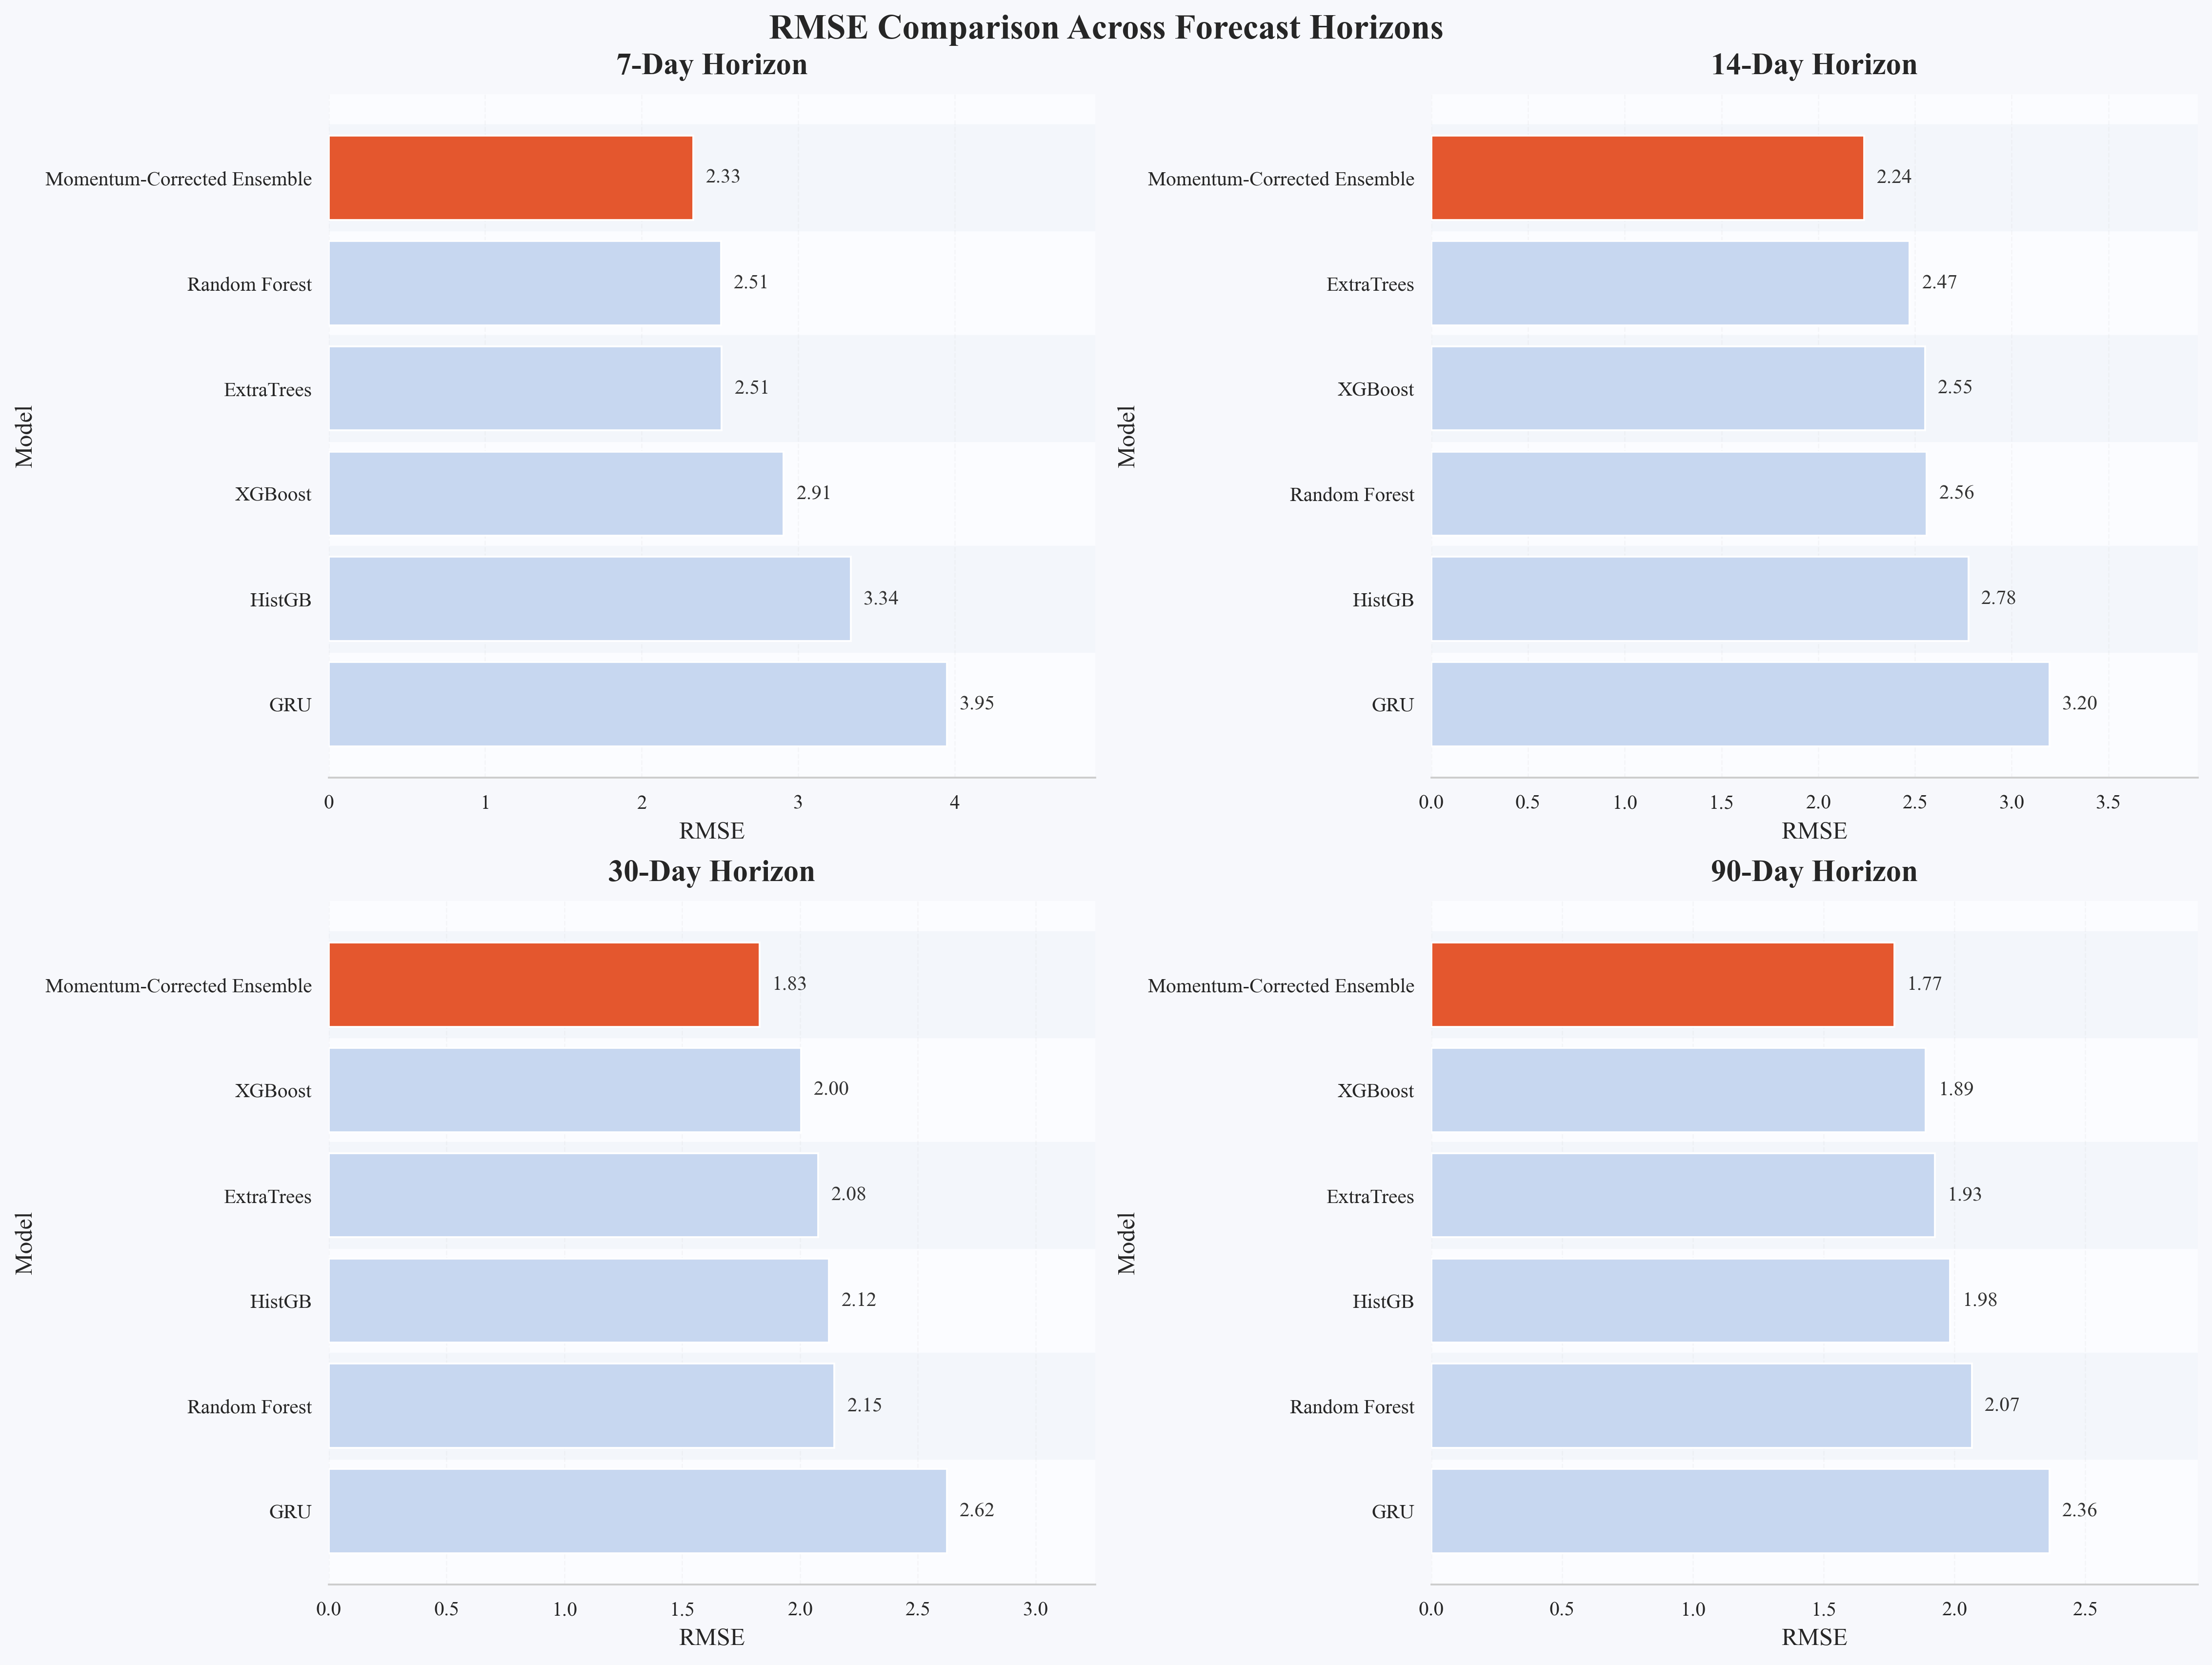

In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.unicode_minus": False,
    "legend.frameon": False,
})

# Colors
best_color = "#E4572E"     # highlight best model
other_color = "#C7D7F0"    # soft blue for remaining bars
fig_bg = "#f7f8fc"
ax_bg = "#fbfcff"

# Load data
comp_df = pd.read_csv("outputs/reports/model_comparison.csv")

bad_models = [
    "NBEATSx", "Naive", "Seasonal_Naive_7", "Auto_ARIMA", "SARIMA",
    "LSTM", "PatchTST", "ARIMA_LSTM", "ARIMA_HistGB"
]
comp_df = comp_df[~comp_df["Model"].isin(bad_models)].copy()

horizons = [7, 14, 30, 90]

name_map = {
    "StackingEnsemble": "Momentum-Corrected Ensemble",
    "XGBoost": "XGBoost",
    "HistGB": "HistGB",
    "ExtraTrees": "ExtraTrees",
    "GRU": "GRU",
    "RandomForest": "Random Forest"
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)
fig.patch.set_facecolor(fig_bg)
axes = axes.ravel()

for ax, h in zip(axes, horizons):
    h_df = comp_df[comp_df["Horizon"] == h].sort_values("RMSE", ascending=True).copy()
    h_df["Display"] = h_df["Model"].map(name_map).fillna(h_df["Model"])
    h_df = h_df.reset_index(drop=True)

    ax.set_facecolor(ax_bg)

    # soft alternating row shading
    for i in range(len(h_df)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color="#f3f6fb", zorder=0)

    colors = [best_color if m == "StackingEnsemble" else other_color for m in h_df["Model"]]

    bars = ax.barh(
        h_df["Display"],
        h_df["RMSE"],
        color=colors,
        edgecolor="white",
        linewidth=0.9,
        zorder=3
    )

    ax.set_title(f"{h}-Day Horizon", pad=10, fontweight="bold")
    ax.invert_yaxis()

    xmax = h_df["RMSE"].max()
    for bar, val in zip(bars, h_df["RMSE"]):
        ax.text(
            val + xmax * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            color="0.20"
        )

    ax.set_xlim(0, xmax * 1.24)
    ax.grid(True, axis="x")
    ax.grid(False, axis="y")
    ax.margins(x=0.02)
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Model")
    sns.despine(ax=ax, left=True, bottom=False)

fig.suptitle("RMSE Comparison Across Forecast Horizons", fontsize=17, fontweight="bold", y=1.02)

save_path = out_dir / "06_model_comparison_rmse_2x2.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)


Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/07_learning_curves_lstm_gru.png


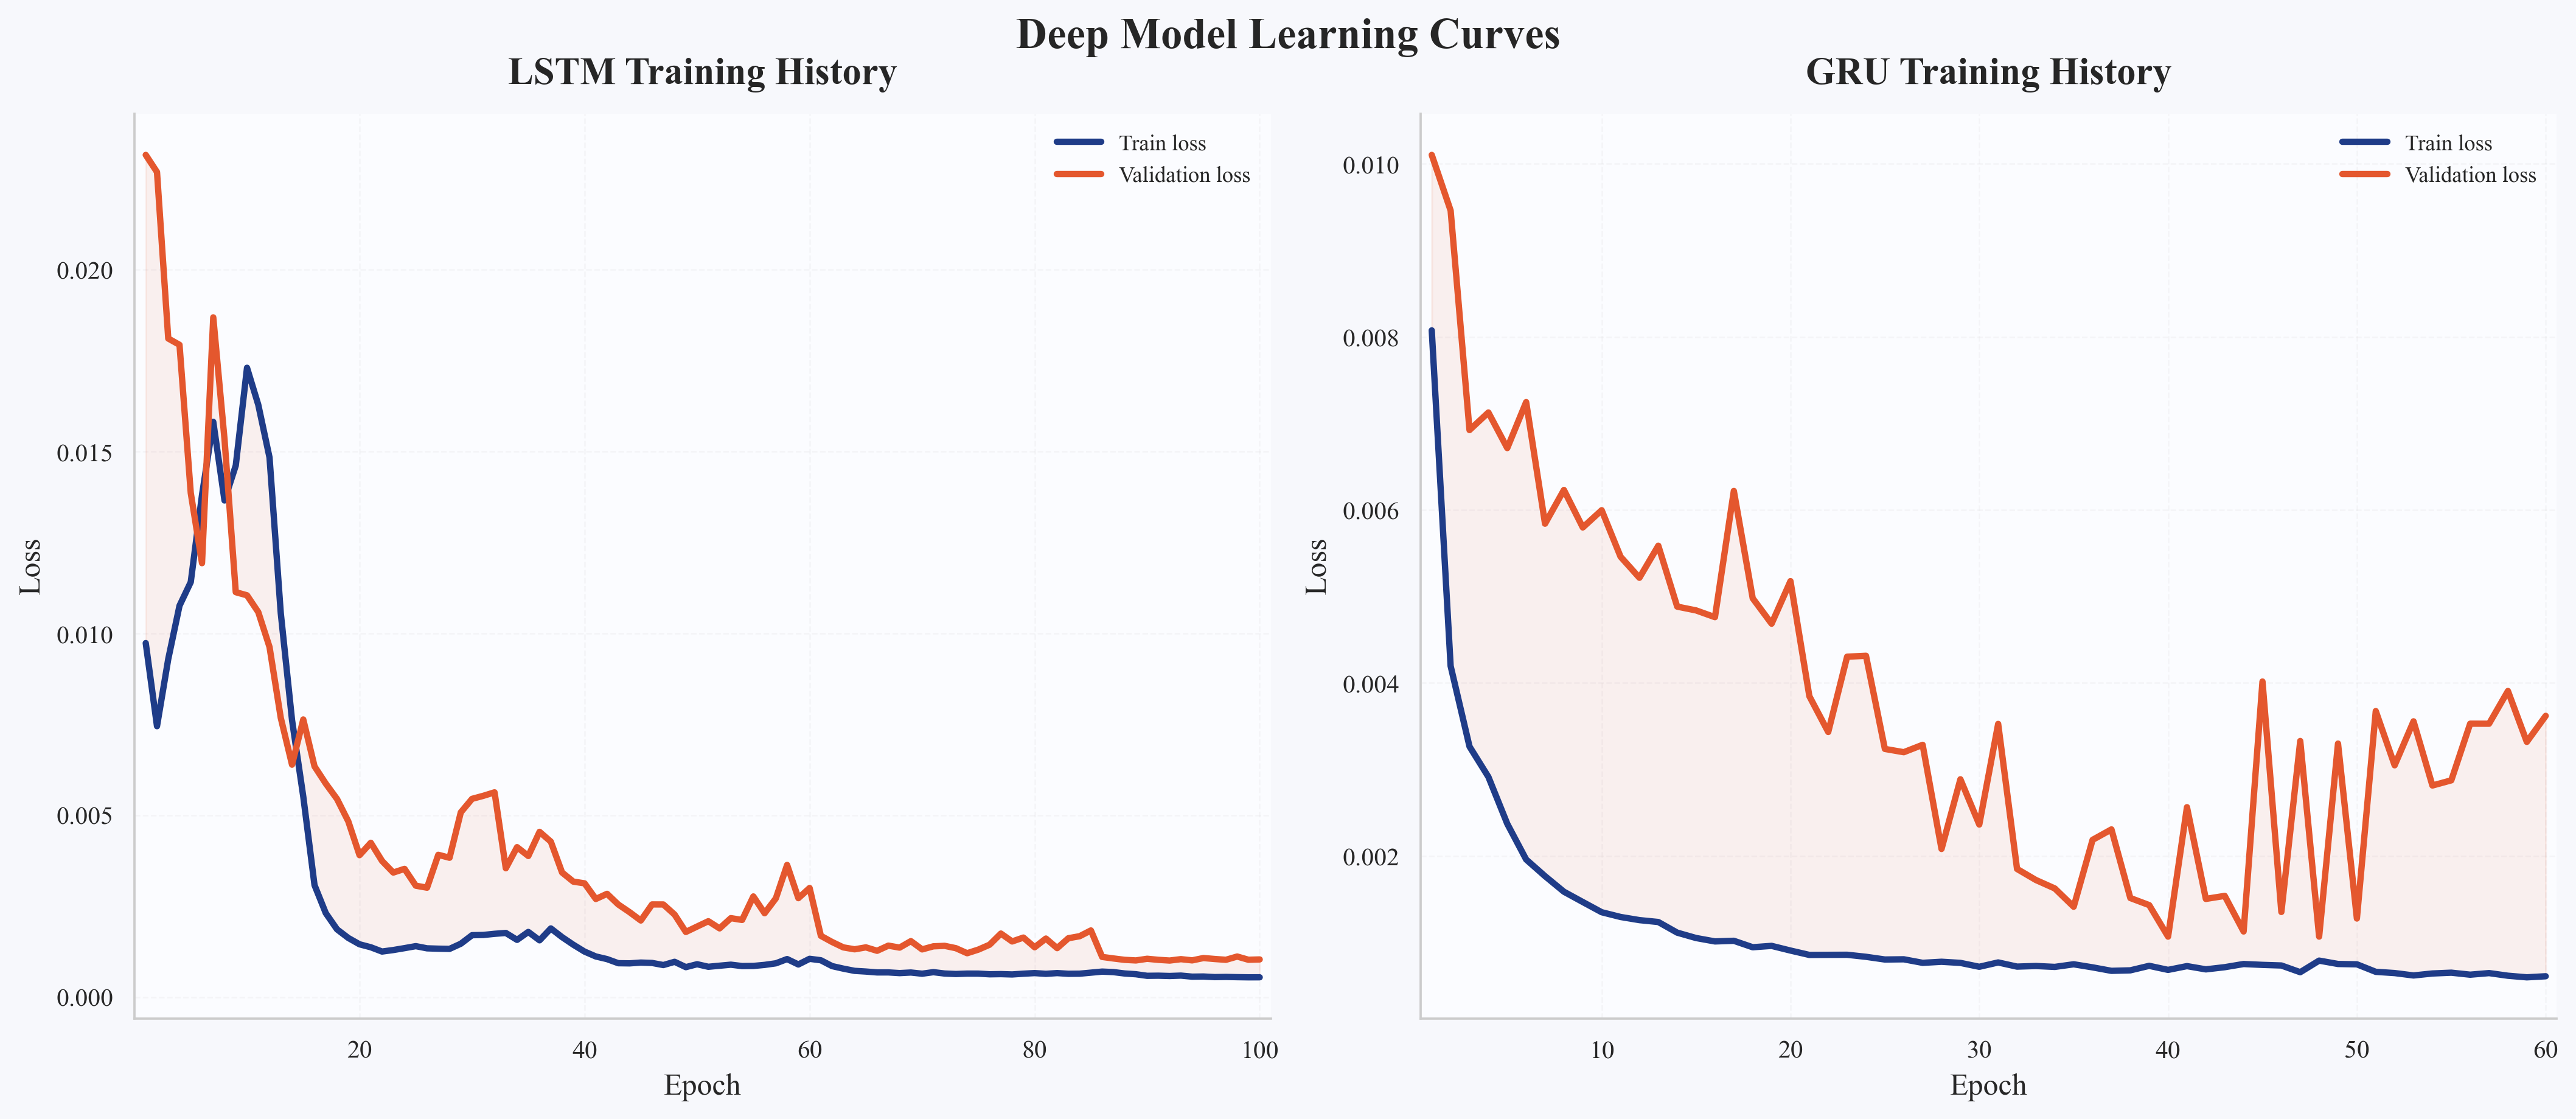

In [8]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.unicode_minus": False,
})

fig_bg = "#f7f8fc"
ax_bg = "#fbfcff"
train_color = "#1F3C88"
val_color = "#E4572E"

lstm = pd.read_csv("outputs/reports/kvpi_lstm_training_history.csv")
gru = pd.read_csv("outputs/reports/kvpi_gru_training_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)
fig.patch.set_facecolor(fig_bg)

panels = [
    (axes[0], lstm, "LSTM Training History"),
    (axes[1], gru, "GRU Training History"),
]

for ax, df, title in panels:
    ax.set_facecolor(ax_bg)
    ax.plot(df["epoch"], df["train_loss"], color=train_color, linewidth=2.5, label="Train loss")
    ax.plot(df["epoch"], df["val_loss"], color=val_color, linewidth=2.5, label="Validation loss")
    ax.fill_between(df["epoch"], df["train_loss"], df["val_loss"], color=val_color, alpha=0.08)
    ax.set_title(title, pad=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, axis="both")
    ax.legend(loc="upper right", frameon=False)
    ax.margins(x=0.01)
    sns.despine(ax=ax)

fig.suptitle("Deep Model Learning Curves", fontsize=17, fontweight="bold", y=1.03)

save_path = out_dir / "07_learning_curves_lstm_gru.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)

Saved to: /Users/sahajrajmalla/Documents/nepal-vegetable-price/kalimati_price_forecasting/outputs/report_figures/08_kvpi_top10_commodity_contributions.png


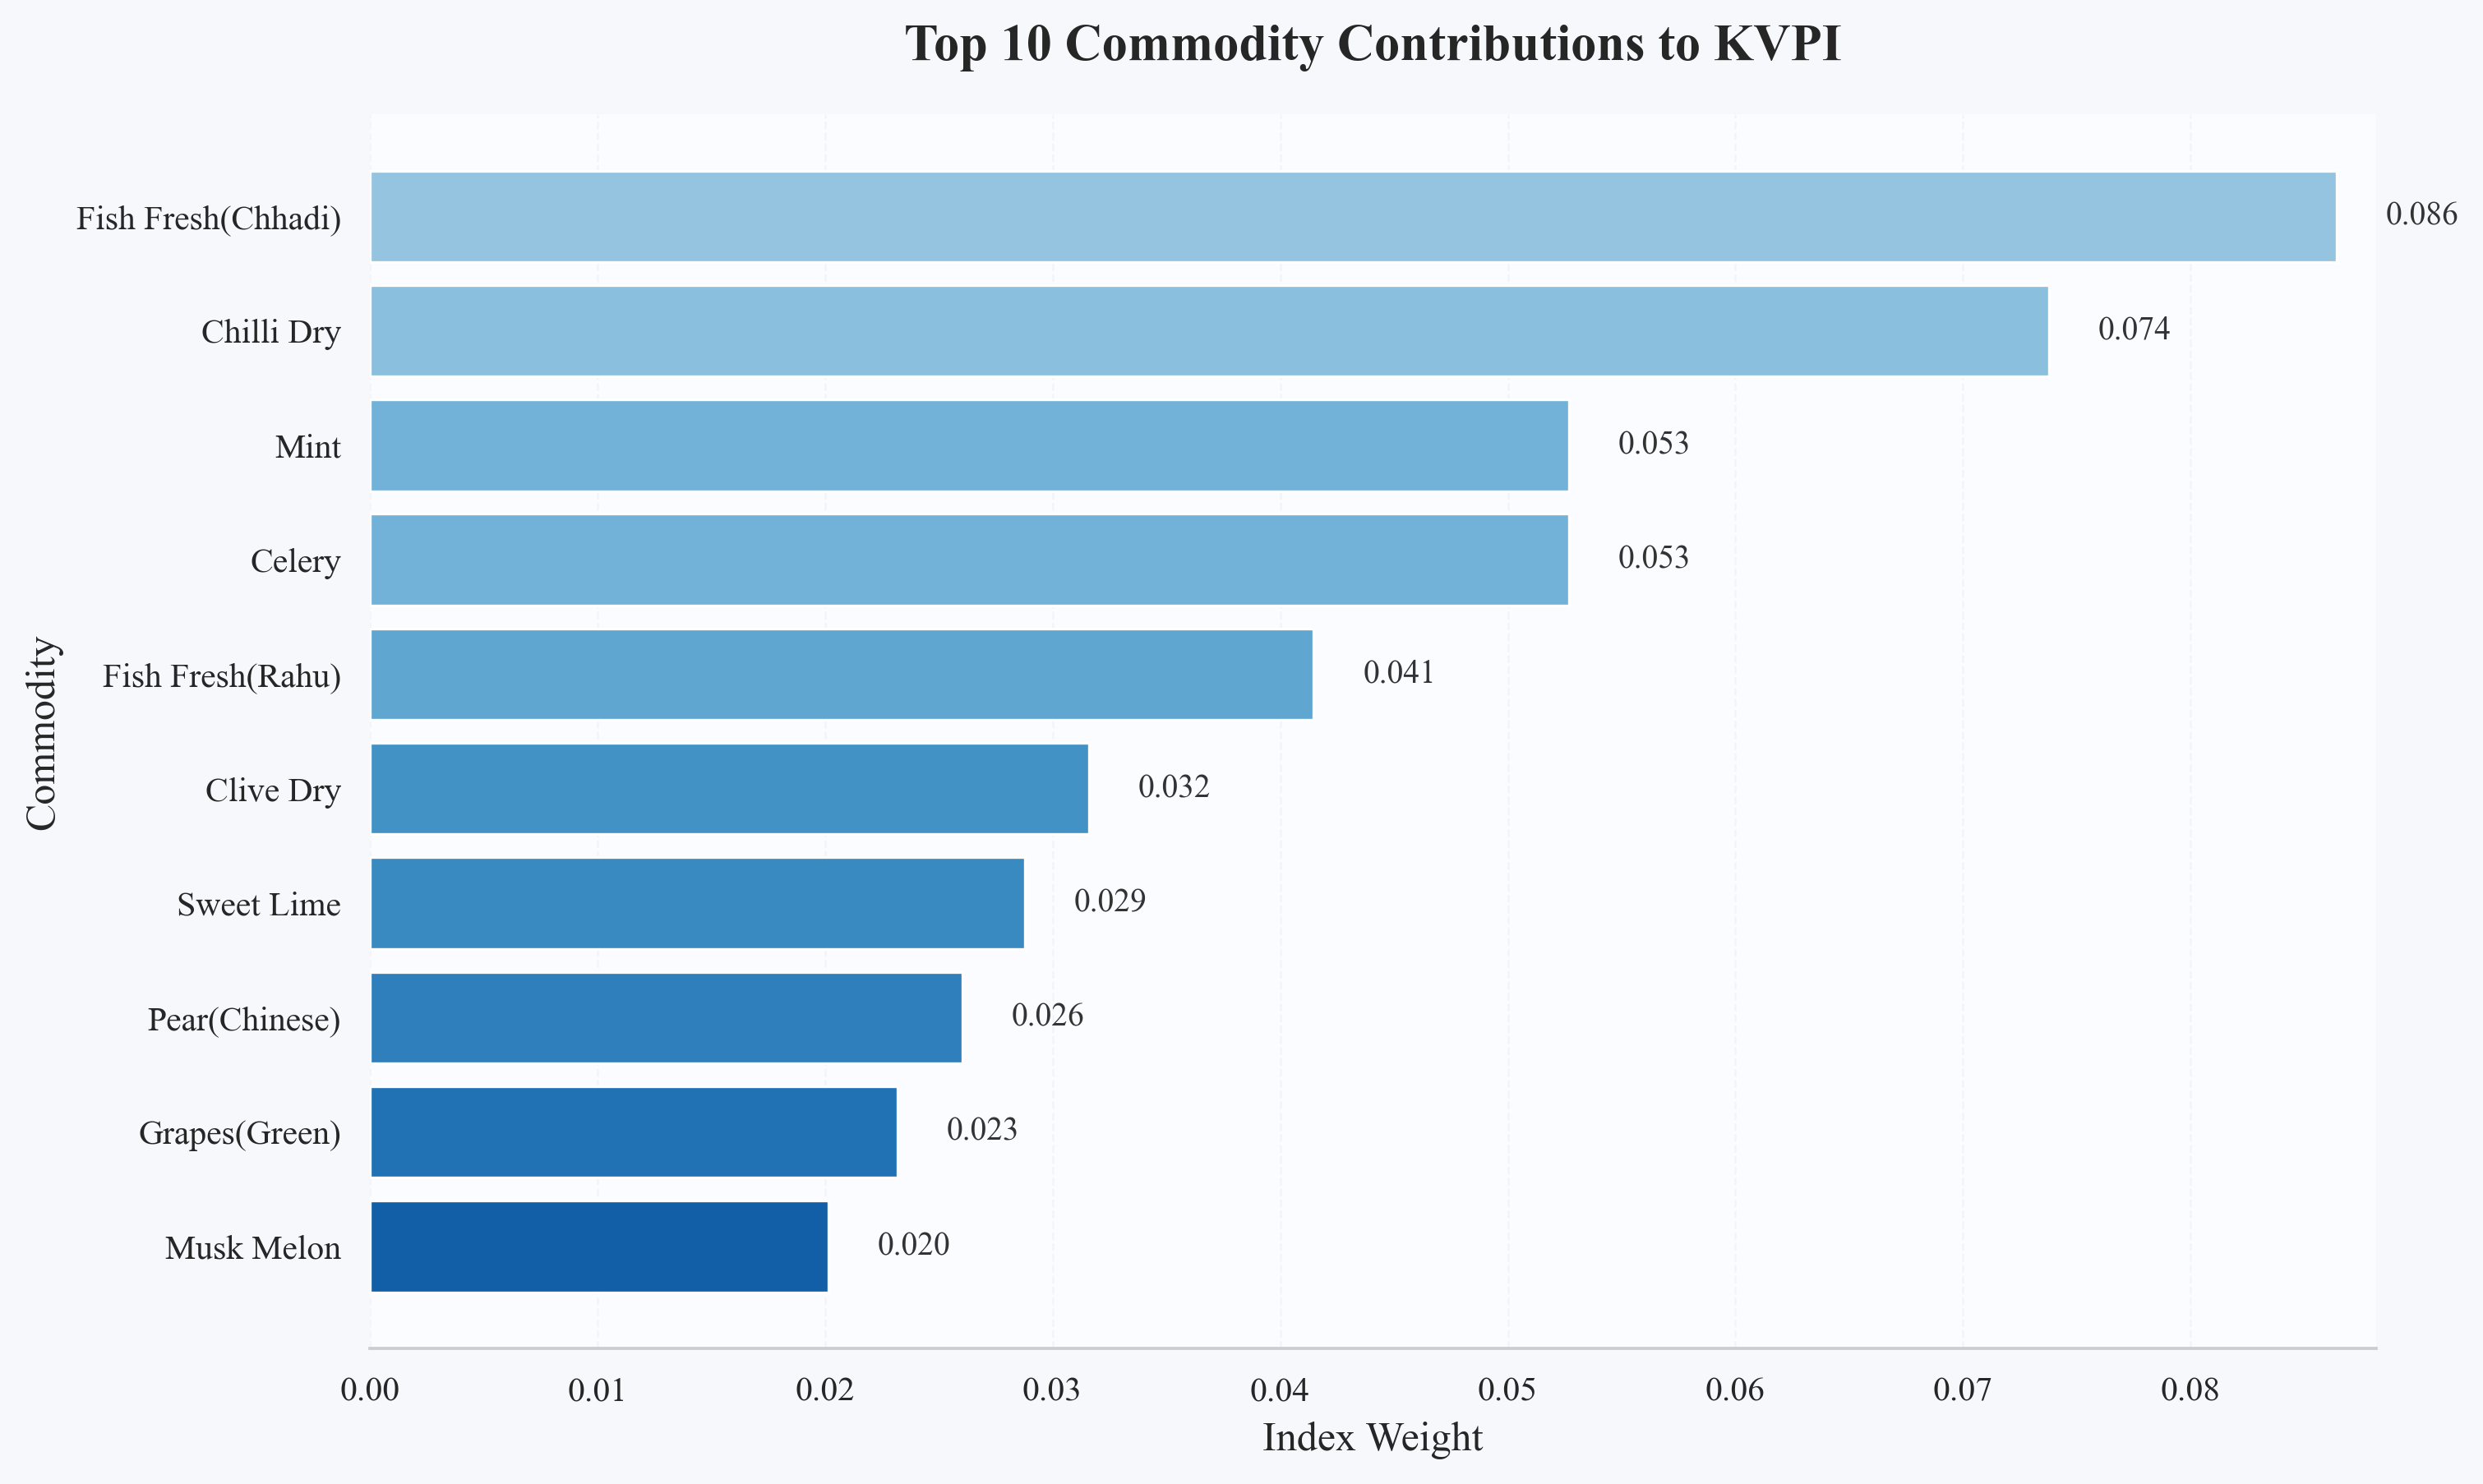

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = Path("outputs/report_figures")
out_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "mathtext.fontset": "stix",
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.unicode_minus": False,
})

df = pd.read_csv("outputs/reports/kvpi_commodity_contributions.csv")
top = df.sort_values("Index_Weight", ascending=False).head(10).copy()
top = top.sort_values("Index_Weight", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 6.5))
fig.patch.set_facecolor("#f7f8fc")
ax.set_facecolor("#fbfcff")

norm = (top["CV_Volatility"] - top["CV_Volatility"].min()) / (top["CV_Volatility"].max() - top["CV_Volatility"].min() + 1e-9)
colors = plt.cm.Blues(0.40 + 0.42 * norm)

bars = ax.barh(
    top["Commodity"],
    top["Index_Weight"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

ax.set_title("Top 10 Commodity Contributions to KVPI", pad=16, fontweight="bold")
ax.set_xlabel("Index Weight")
ax.set_ylabel("Commodity")

xmax = top["Index_Weight"].max()
for bar, val in zip(bars, top["Index_Weight"]):
    ax.text(
        val + xmax * 0.025,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=9.5,
        color="0.20"
    )

ax.grid(True, axis="x")
ax.grid(False, axis="y")
ax.margins(x=0.02)
sns.despine(ax=ax, left=True, bottom=False)

save_path = out_dir / "08_kvpi_top10_commodity_contributions.png"
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {save_path.resolve()}")

plt.show()
plt.close(fig)